# Time Series Forecasting using RNN with LSTM

In this project, we build and train a Recurrent Neural Network (RNN) with LSTM cells to model and forecast time series data (sine wave). The model learns temporal patterns by using past observations to predict future values, overcoming the limitations of simple RNNs such as vanishing gradients. After training, the model is saved and reloaded for generating future predictions, demonstrating how sequence models can capture dependencies over time for forecasting tasks.

In [74]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [75]:
x = torch.linspace(0,799,800)

In [76]:
y = torch.sin(x*2*np.pi/40)

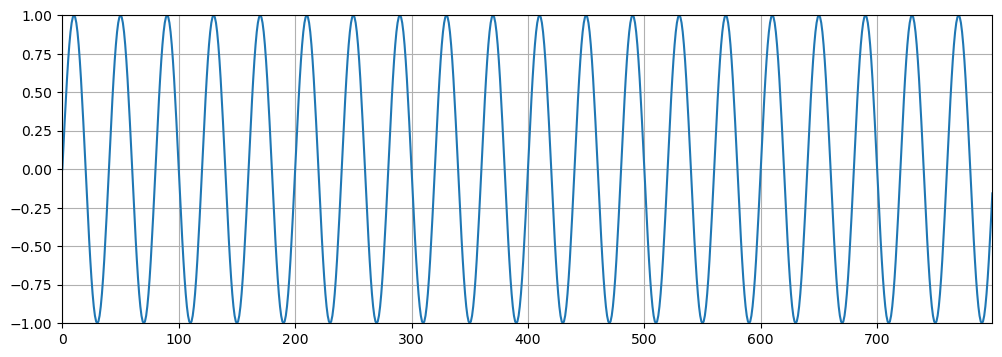

In [77]:
plt.figure(figsize=(12,4))
plt.ylim(-1,1)
plt.xlim(0,799)
plt.grid(True)
plt.plot(y)

## Train-Test split

We will split the sine data into two parts:

x = [0, -40]   ---> Training set

x = [-40, end] ---> Testing set

Later, we will calculate the predicted/forecasted value and cross-check it with the actual value.

In [78]:
test_size = 40
train_set = y[:-test_size]
test_set = y[-test_size:]

seq --> Sequence

ws --> Window size

In [79]:
def input_data(seq,ws):
    out = []
    L = len(seq)

    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))

    return out

In [80]:
window_size = 40
train_data = input_data(train_set,window_size)

In [81]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Add an LSTM layer:
        self.lstm = nn.LSTM(input_size,hidden_size)
        
        # Add a fully-connected layer:
        self.linear = nn.Linear(hidden_size,out_size)
        
        # Initialize h0 and c0:
        self.hidden = (torch.zeros(1,1,hidden_size),
                       torch.zeros(1,1,hidden_size))
    
    def forward(self,seq):
        lstm_out, self.hidden = self.lstm(
            seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]   # we only care about the last prediction

In [82]:
torch.manual_seed(42)
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [83]:
model

LSTM(
  (lstm): LSTM(1, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [84]:
parameters_sum = 0
for p in model.parameters():
    print(p.numel())
    parameters_sum += p.numel()

print(f'------\n{parameters_sum}')

200
10000
200
200
50
1
------
10651


## Train and simultaneously evaluate the model
We'll train 10 epochs. For clarity, we'll "zoom in" on the test set, and only display from point 700 to the end.

epoch: 1, loss: 0.09209895133972168


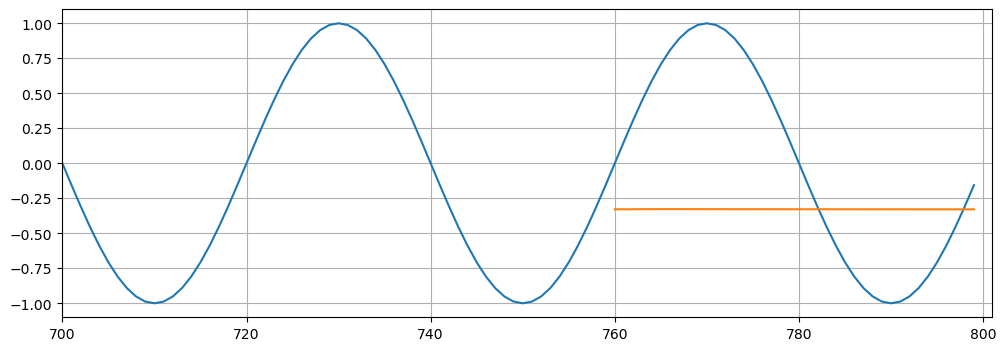

epoch: 2, loss: 0.06505247950553894


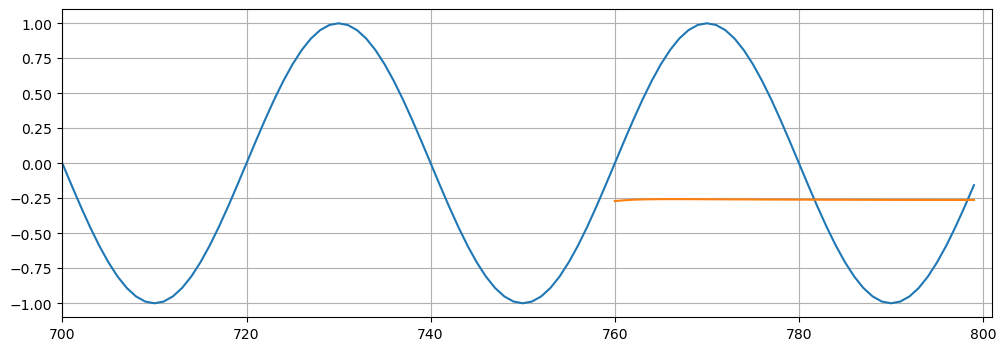

epoch: 3, loss: 0.04197341948747635


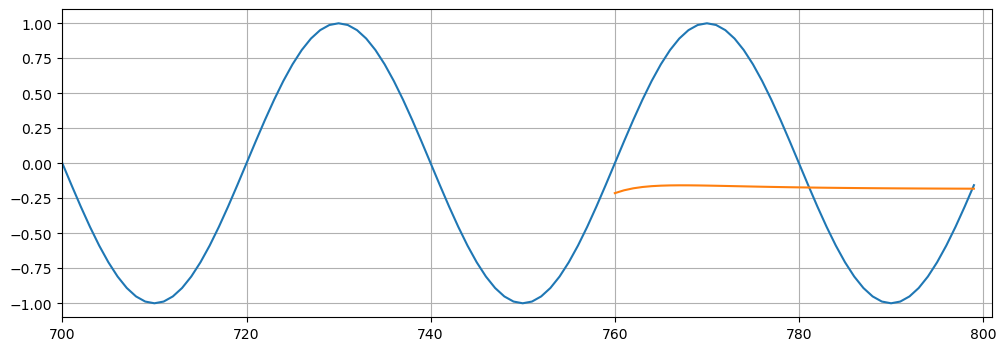

epoch: 4, loss: 0.017842350527644157


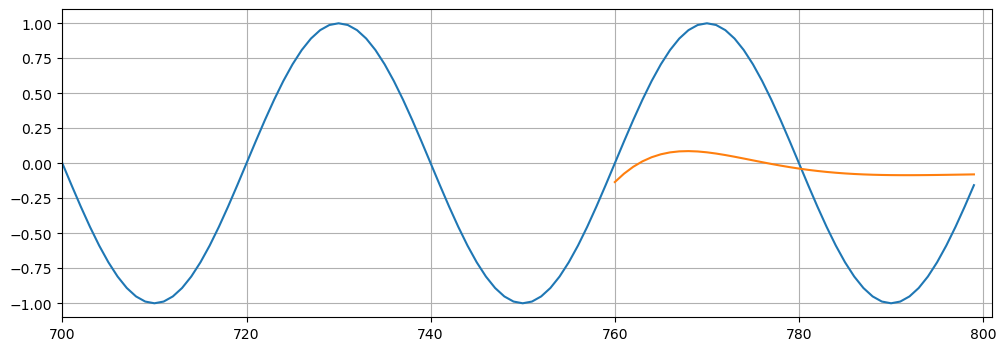

epoch: 5, loss: 0.00288904900662601


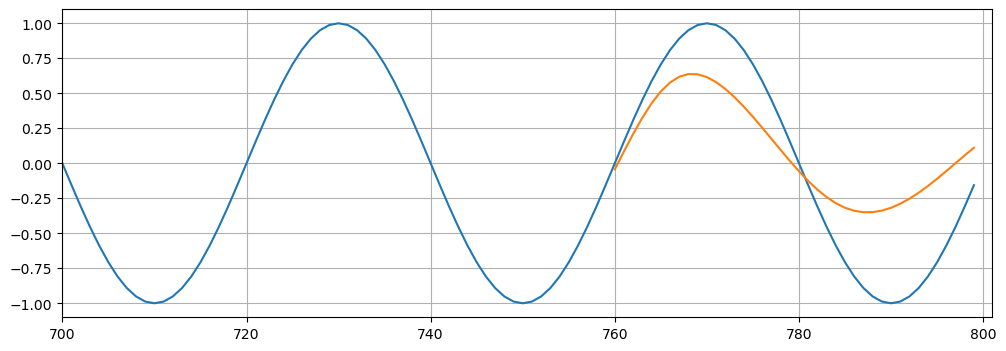

epoch: 6, loss: 0.00032107040169648826


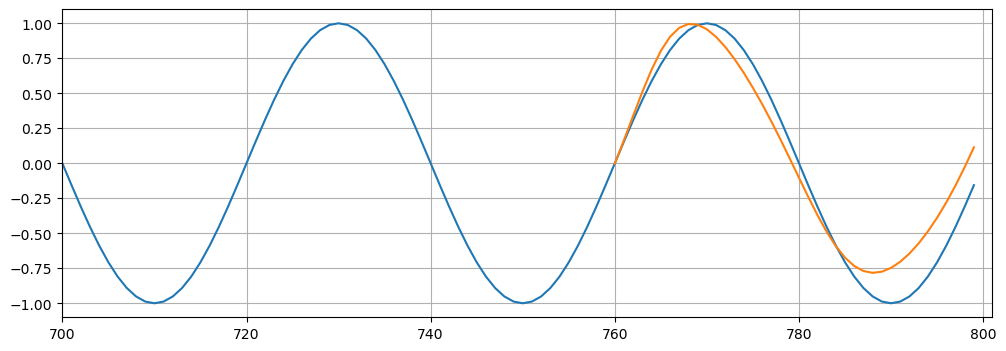

epoch: 7, loss: 0.00013034962466917932


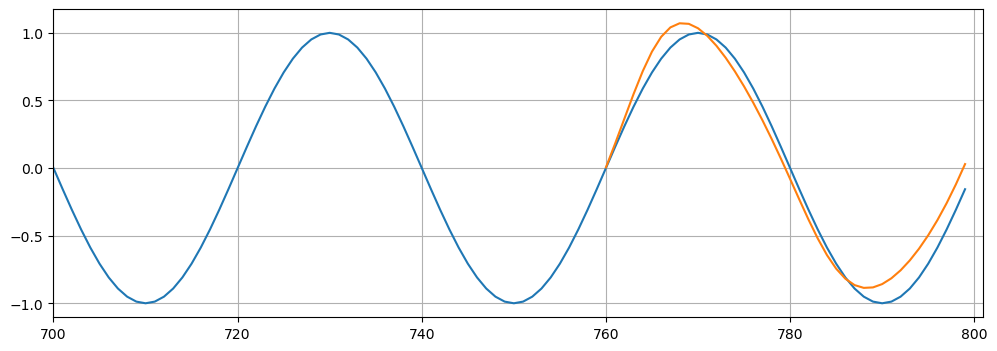

epoch: 8, loss: 0.0001206846718559973


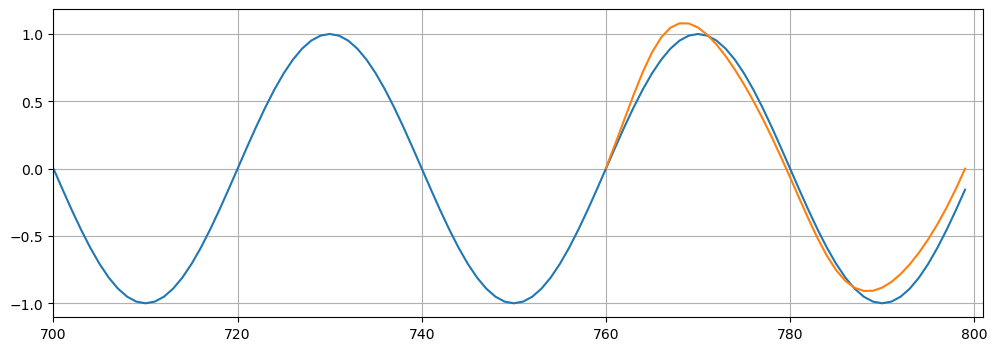

epoch: 9, loss: 0.0001271718501811847


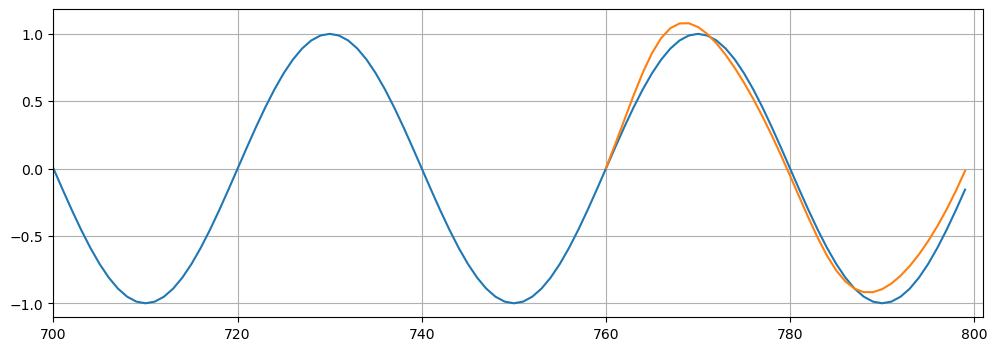

epoch: 10, loss: 0.00013256551756057888


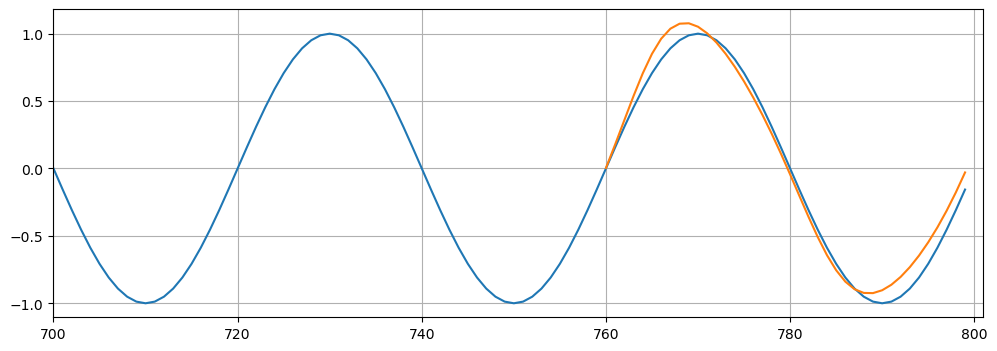

In [85]:
epochs = 10
future_pred_size = 40
# pred = y[-window_size:]
for i in range(epochs):

    # As we have tuple in each element in input_data, we have to unpack before we use it.
    for seq,y_train in train_data:
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        y_pred = model(seq)
        loss = criterion(y_train,y_pred)
        loss.backward()
        optimizer.step()

    print(f'epoch: {i+1}, loss: {loss}')

    y_future = train_set[-window_size:].tolist()
    for i in range(future_pred_size):
        y_seq = torch.FloatTensor(y_future[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),
                            torch.zeros(1,1,model.hidden_size))
            y_future.append(model(y_seq).item())

    # Plot from point 700 to the end
    plt.figure(figsize=(12,4))
    plt.xlim(700,801)
    plt.grid(True)
    plt.plot(y.numpy())
    plt.plot(range(760,800),y_future[window_size:])
    plt.show()

## Save the model

In [86]:
torch.save(model.state_dict(), "RNN_Sine_wave_weights.pth")

## Predict the next 40 points

/var/folders/4f/syjztfg11q58x5r6mwvfryp40000gn/T/ipykernel_84322/547019623.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("RNN_Sine_wav

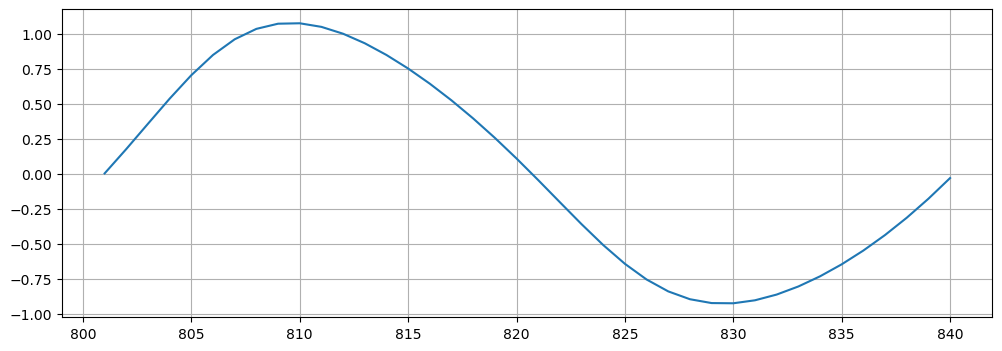

In [87]:
# Reload trained model
model = LSTM()
model.load_state_dict(torch.load("RNN_Sine_wave_weights.pth"))
model.eval()

# Start with the last window of test data
y_future_unknown = test_set[-window_size:].tolist()

# Reset hidden state once
model.hidden = (torch.zeros(1, 1, model.hidden_size),
                torch.zeros(1, 1, model.hidden_size))

# Generate predictions
for i in range(future_pred_size):
    y_seq = torch.FloatTensor(y_future_unknown[-window_size:])
    with torch.no_grad():
        pred = model(y_seq).item()
    y_future_unknown.append(pred)

# Plot predictions
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(range(801, 841), y_future_unknown[-future_pred_size:])
plt.show()